In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [ ]:
from pathlib import Path

DATA_DIR = Path("data")

requests_train = pd.read_csv(
    DATA_DIR / "requests_train_clean.csv",
    low_memory=False
)

requests_test = pd.read_csv(
    DATA_DIR / "requests_test_clean.csv",
    low_memory=False
)

individuals_train = pd.read_csv(
    DATA_DIR / "individuals_train_clean.csv",
    low_memory=False
)

individuals_test = pd.read_csv(
    DATA_DIR / "individuals_test_clean.csv",
    low_memory=False
)

# CSV type

In [57]:
request_date_columns = [
    "answer_creation_date",
    "group_creation_date",
    "request_creation_date"
]

for column in request_date_columns:
    requests_train[column] = pd.to_datetime(
        requests_train[column],
        errors="coerce"
    )

    requests_test[column] = pd.to_datetime(
        requests_test[column],
        errors="coerce"
    )

individuals_train["individual_creation_date"] = pd.to_datetime(
    individuals_train["individual_creation_date"],
    errors="coerce"
)

individuals_test["individual_creation_date"] = pd.to_datetime(
    individuals_test["individual_creation_date"],
    errors="coerce"
)

In [58]:
request_categorical_ids = [
    "child_situation",
    "district",
    "group_composition_id",
    "housing_situation_id"
]

individual_categorical_ids = [
    "housing_situation_2_id",
    "individual_role_2_id",
    "marital_status_id"
]

for column in request_categorical_ids:
    requests_train[column] = requests_train[column].astype(str)
    requests_test[column] = requests_test[column].astype(str)

for column in individual_categorical_ids:
    individuals_train[column] = individuals_train[column].astype(str)
    individuals_test[column] = individuals_test[column].astype(str)

In [59]:
print("requests_train :", requests_train.shape)
print("requests_test :", requests_test.shape)
print("individuals_train :", individuals_train.shape)
print("individuals_test :", individuals_test.shape)

display(requests_train.head())
display(individuals_train.head())

requests_train : (238191, 25)
requests_test : (59548, 25)
individuals_train : (384133, 17)
individuals_test : (95641, 17)


,request_id,animal_presence,answer_creation_date,child_situation,child_to_come,district,granted_number_of_nights,group_composition_id,group_composition_label,group_creation_date,group_id,group_main_requester_id,group_type,housing_situation_id,housing_situation_label,long_term_housing_request,number_of_underage,request_backoffice_creator_id,request_creation_date,requester_type,social_situation_id,town,victim_of_violence,victim_of_violence_type,number_of_underage_missing
0,130667d2964de43c511d0ead7ac66b33,f,2019-02-11 22:30:00.000,unknown,unknown,85,1,10,man alone,2018-05-03 12:10:40.416,c62f692dcc3f31880dd3937369c6f9e1,56252a8182a732cad0d106328bf96a0b,individual,160,other,unknown,NaN,eecd6110b7e9157e6423428b22a28159,2019-02-11 22:30:00.000,third party,9a84febc47fedaf2c81d7c755e9edc85,unknown,f,no_violence,1
1,b1cd62fcf24eebb0f685d5eaf55317a8,f,2019-02-12 09:00:00.000,unknown,unknown,85,1,10,man alone,2019-03-07 12:11:08.545,cbb3ae0239a3ca9a0441831bde02aaa3,b23d21c9973e5b74504a94eebe82fb75,individual,160,other,unknown,NaN,eecd6110b7e9157e6423428b22a28159,2019-02-12 09:00:00.000,user,11f64f0547e855c5c59329b9edc63063,unknown,f,no_violence,1
2,12cc0a18890bd4959fe42df3ae58838e,f,2019-02-01 21:00:00.000,unknown,unknown,59,1,80,isolated child/underage,2019-03-13 12:54:15.887,a73d85877e940fd36ac23bb80ac7fbbe,5e063c21a61a5b38f8f21baebea86f50,individual,200,street,unknown,NaN,686d962128c7622aa79ed91da13f5c77,2019-02-01 21:00:00.000,user,898ab2883f410f4c6fb042ef16329fbb,unknown,f,no_violence,1
3,ae2d5b4dc181d29e430132f145da1556,f,2019-02-25 15:12:05.037,unknown,unknown,50,2,20,woman alone,2018-10-09 14:37:29.773,5f69b8b928f84ce1e673740acb854af2,f46e831e036fe418d88d6d40ee4b0680,individual,170,unknown,unknown,NaN,ec29519464c381a6630f4e480a0c000e,2019-02-25 15:12:05.037,user,3998c8e890ddc980527dd1af45dfa672,unknown,t,woman,1
4,d13a17ce36c832514fda2464e11c4a9f,f,2019-02-20 09:59:20.603,unknown,unknown,93,2,60,group with child(ren),2018-10-02 10:47:36.931,df3a2364091c2aa9f90f2738f6b176f1,936ae1e1737f38e8f9ef3049805629f3,group,50,hotel paid by the emergency centre,unknown,NaN,c8b5cc926b1d7212224a08baa9619518,2019-02-20 09:59:20.603,user,74a10d96eae43586bc3c46e89719b821,unknown,f,no_violence,1


,request_id,individual_id,housing_situation_2_id,housing_situation_2_label,birth_month,birth_year,childcare_center_supervision,disabled_worker_certification,gender,individual_creation_date,individual_role,individual_role_2_id,individual_role_2_label,marital_status_id,marital_status_label,pregnancy,individual_creation_date_missing
0,130667d2964de43c511d0ead7ac66b33,b24a8cfaaf3663bac45ca3bcd24f0b36,20,on the street,5,1977,not_applicable,unknown,male,2018-01-29,isolated person,30,isolated adult,10,single person,f,0
1,b1cd62fcf24eebb0f685d5eaf55317a8,eef783d1bda82661a751c12c34aff8c2,20,on the street,5,1980,not_applicable,unknown,male,2019-03-07,unknown,30,isolated adult,unknown,unknown,f,0
2,12cc0a18890bd4959fe42df3ae58838e,927b6fa58d6be263c411332835b11fec,20,on the street,1,2003,unknown,not_applicable,male,2019-03-13,unknown,10,isolated underage/child,unknown,not_applicable,f,0
3,ae2d5b4dc181d29e430132f145da1556,94181d5cf4a56cc84d12677df84e2e03,20,on the street,7,1986,not_applicable,unknown,female,2018-10-09,unknown,30,isolated adult,unknown,unknown,f,0
4,d13a17ce36c832514fda2464e11c4a9f,e79d2e3f9ace50049f1796c098008c13,35,hotel paid by the emergency structure,9,1980,not_applicable,unknown,female,2017-06-22,husband/spouse,1,partner,unknown,unknown,f,0


In [60]:
print("Types de requests_train :")
display(requests_train.dtypes)

print("\nTypes de requests_test :")
display(requests_test.dtypes)

print("\nTypes de individuals_train :")
display(individuals_train.dtypes)

print("\nTypes de individuals_test :")
display(individuals_test.dtypes)

Types de requests_train :


request_id                               object
animal_presence                          object
answer_creation_date             datetime64[ns]
child_situation                          object
child_to_come                            object
district                                 object
granted_number_of_nights                  int64
group_composition_id                     object
group_composition_label                  object
group_creation_date              datetime64[ns]
group_id                                 object
group_main_requester_id                  object
group_type                               object
housing_situation_id                     object
housing_situation_label                  object
long_term_housing_request                object
number_of_underage                      float64
request_backoffice_creator_id            object
request_creation_date            datetime64[ns]
requester_type                           object
social_situation_id                     


Types de requests_test :


request_id                               object
animal_presence                          object
answer_creation_date             datetime64[ns]
child_situation                          object
child_to_come                            object
district                                 object
granted_number_of_nights                  int64
group_composition_id                     object
group_composition_label                  object
group_creation_date              datetime64[ns]
group_id                                 object
group_main_requester_id                  object
group_type                               object
housing_situation_id                     object
housing_situation_label                  object
long_term_housing_request                object
number_of_underage                      float64
request_backoffice_creator_id            object
request_creation_date            datetime64[ns]
requester_type                           object
social_situation_id                     


Types de individuals_train :


request_id                                  object
individual_id                               object
housing_situation_2_id                      object
housing_situation_2_label                   object
birth_month                                  int64
birth_year                                   int64
childcare_center_supervision                object
disabled_worker_certification               object
gender                                      object
individual_creation_date            datetime64[ns]
individual_role                             object
individual_role_2_id                        object
individual_role_2_label                     object
marital_status_id                           object
marital_status_label                        object
pregnancy                                   object
individual_creation_date_missing             int64
dtype: object


Types de individuals_test :


request_id                                  object
individual_id                               object
housing_situation_2_id                      object
housing_situation_2_label                   object
birth_month                                float64
birth_year                                 float64
childcare_center_supervision                object
disabled_worker_certification               object
gender                                      object
individual_creation_date            datetime64[ns]
individual_role                             object
individual_role_2_id                        object
individual_role_2_label                     object
marital_status_id                           object
marital_status_label                        object
pregnancy                                   object
individual_creation_date_missing             int64
dtype: object

# Constitution des features

In [61]:
individual_features_train = (
    individuals_train
    .groupby("request_id")
    .agg(
        number_of_individuals=("individual_id", "nunique")
    )
    .reset_index()
)

individual_features_test = (
    individuals_test
    .groupby("request_id")
    .agg(
        number_of_individuals=("individual_id", "nunique")
    )
    .reset_index()
)

In [62]:
display(individual_features_train.head(20))

print(
    "Nombre de demandes dans les features train :",
    individual_features_train.shape[0]
)

print(
    "Nombre de demandes dans les features test :",
    individual_features_test.shape[0]
)

,request_id,number_of_individuals
0,0000602749161524aedd04269957e5fc,1
1,0000c66f6bb24e930cba6a3872d3ab02,1
2,0000dbd253c096eab97cab0545915ab2,1
3,0001826bdd626262ec2bda3a1b908aac,1
4,0001925b4cd4d65110638ee3d5f2f454,1
5,0001a495ad47ad6587cd812bb0dc2818,5
6,0001e5facbb036e4853eaebef491567a,5
7,00024a3ee0b5836078d625598876f63d,1
8,00025e6dc841a67efca4b780efa69ee1,1
9,00029e888d15d0a85a8db059e9b47f25,1


Nombre de demandes dans les features train : 238191
Nombre de demandes dans les features test : 59548


In [63]:
def calculate_age(individuals, requests):
    df = individuals.merge(
        requests[["request_id", "request_creation_date"]],
        on="request_id",
        how="left",
        validate="many_to_one"
    )

    df["age"] = (
        df["request_creation_date"].dt.year
        - df["birth_year"]
        - (
            df["request_creation_date"].dt.month
            < df["birth_month"]
        ).astype(int)
    )

    # Si l'année ou le mois de naissance est absent,
    # l'âge doit aussi être considéré comme manquant
    missing_birth_information = (
        df["birth_year"].isna()
        | df["birth_month"].isna()
        | df["request_creation_date"].isna()
    )

    df.loc[missing_birth_information, "age"] = np.nan

    # Suppression logique des âges impossibles
    df.loc[~df["age"].between(0, 110), "age"] = np.nan

    return df

In [64]:
individuals_train_enriched = calculate_age(
    individuals_train,
    requests_train
)

individuals_test_enriched = calculate_age(
    individuals_test,
    requests_test
)

In [65]:
individuals_train_enriched

,request_id,individual_id,housing_situation_2_id,housing_situation_2_label,birth_month,birth_year,childcare_center_supervision,disabled_worker_certification,gender,individual_creation_date,individual_role,individual_role_2_id,individual_role_2_label,marital_status_id,marital_status_label,pregnancy,individual_creation_date_missing,request_creation_date,age
0,130667d2964de43c511d0ead7ac66b33,b24a8cfaaf3663bac45ca3bcd24f0b36,20,on the street,5,1977,not_applicable,unknown,male,2018-01-29,isolated person,30,isolated adult,10,single person,f,0,2019-02-11 22:30:00.000,41.0
1,b1cd62fcf24eebb0f685d5eaf55317a8,eef783d1bda82661a751c12c34aff8c2,20,on the street,5,1980,not_applicable,unknown,male,2019-03-07,unknown,30,isolated adult,unknown,unknown,f,0,2019-02-12 09:00:00.000,38.0
2,12cc0a18890bd4959fe42df3ae58838e,927b6fa58d6be263c411332835b11fec,20,on the street,1,2003,unknown,not_applicable,male,2019-03-13,unknown,10,isolated underage/child,unknown,not_applicable,f,0,2019-02-01 21:00:00.000,16.0
3,ae2d5b4dc181d29e430132f145da1556,94181d5cf4a56cc84d12677df84e2e03,20,on the street,7,1986,not_applicable,unknown,female,2018-10-09,unknown,30,isolated adult,unknown,unknown,f,0,2019-02-25 15:12:05.037,32.0
4,d13a17ce36c832514fda2464e11c4a9f,e79d2e3f9ace50049f1796c098008c13,35,hotel paid by the emergency structure,9,1980,not_applicable,unknown,female,2017-06-22,husband/spouse,1,partner,unknown,unknown,f,0,2019-02-20 09:59:20.603,38.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384128,f1c688b7955bd0c719265e6eae9a2944,1de037d4226b878768219cd5132bdeaa,35,hotel paid by the emergency structure,4,2008,unknown,not_applicable,male,2018-10-30,unknown,70,child/underage with family,10,single person,f,0,2019-01-07 14:09:20.226,10.0
384129,079e909872f80a37bc2843431f0f061c,bdc57b5009031ebe15f7fb856dc1f1aa,35,hotel paid by the emergency structure,5,1986,not_applicable,f,female,2018-07-11,isolated parent,40,isolated parent,10,single person,f,0,2019-01-08 10:11:18.117,32.0
384130,079e909872f80a37bc2843431f0f061c,da7164fdb0d0486d5892b4cdf2021841,35,hotel paid by the emergency structure,12,2017,unknown,f,female,2018-09-25,child,70,child/underage with family,unknown,not_applicable,f,0,2019-01-08 10:11:18.117,1.0
384131,28f69de558f45d0279ef940e67285215,7b95310e30f6e4f6c6b3a62a4b5d4fab,20,on the street,7,1982,not_applicable,f,male,2019-01-05,partner,50,husband/spouse,20,married,f,0,2019-01-08 18:15:04.115,36.0


In [66]:
age_features_train = (
    individuals_train_enriched
    .groupby("request_id")
    .agg(
        age_mean=("age", "mean"),
        age_min=("age", "min"),
        age_max=("age", "max"),
        number_of_minors_calculated=(
            "age",
            lambda ages: (ages < 18).sum()
        ),
        number_of_adults_calculated=(
            "age",
            lambda ages: (ages >= 18).sum()
        ),
        number_of_missing_ages=(
            "age",
            lambda ages: ages.isna().sum()
        )
    )
    .reset_index()
)

In [67]:
age_features_test = (
    individuals_test_enriched
    .groupby("request_id")
    .agg(
        age_mean=("age", "mean"),
        age_min=("age", "min"),
        age_max=("age", "max"),
        number_of_minors_calculated=(
            "age",
            lambda ages: (ages < 18).sum()
        ),
        number_of_adults_calculated=(
            "age",
            lambda ages: (ages >= 18).sum()
        ),
        number_of_missing_ages=(
            "age",
            lambda ages: ages.isna().sum()
        )
    )
    .reset_index()
)

In [68]:
individual_features_train = individual_features_train.merge(
    age_features_train,
    on="request_id",
    how="left",
    validate="one_to_one"
)

individual_features_test = individual_features_test.merge(
    age_features_test,
    on="request_id",
    how="left",
    validate="one_to_one"
)

In [69]:
display(individual_features_train.head())

,request_id,number_of_individuals,age_mean,age_min,age_max,number_of_minors_calculated,number_of_adults_calculated,number_of_missing_ages
0,0000602749161524aedd04269957e5fc,1,23.0,23.0,23.0,0,1,0
1,0000c66f6bb24e930cba6a3872d3ab02,1,37.0,37.0,37.0,0,1,0
2,0000dbd253c096eab97cab0545915ab2,1,18.0,18.0,18.0,0,1,0
3,0001826bdd626262ec2bda3a1b908aac,1,38.0,38.0,38.0,0,1,0
4,0001925b4cd4d65110638ee3d5f2f454,1,25.0,25.0,25.0,0,1,0


In [70]:
def create_demographic_and_vulnerability_features(individuals):
    df = individuals.copy()

    # Transformation de chaque caractéristique en indicateur 0/1
    df["is_female"] = (df["gender"] == "female").astype(int)
    df["is_male"] = (df["gender"] == "male").astype(int)
    df["is_pregnant"] = (df["pregnancy"] == "t").astype(int)

    df["is_disabled_worker"] = (
        df["disabled_worker_certification"] == "t"
    ).astype(int)

    df["has_childcare_supervision"] = (
        df["childcare_center_supervision"] == "t"
    ).astype(int)

    df["is_isolated_parent"] = (
        df["individual_role_2_label"] == "isolated parent"
    ).astype(int)

    df["is_isolated_minor"] = (
        df["individual_role_2_label"]
        == "isolated underage/child"
    ).astype(int)

    # Agrégation par demande
    features = (
        df.groupby("request_id")
        .agg(
            number_of_females=("is_female", "sum"),
            number_of_males=("is_male", "sum"),
            number_of_pregnant_people=("is_pregnant", "sum"),
            number_of_disabled_workers=("is_disabled_worker", "sum"),
            number_with_childcare_supervision=(
                "has_childcare_supervision",
                "sum"
            ),
            has_isolated_parent=("is_isolated_parent", "max"),
            has_isolated_minor=("is_isolated_minor", "max")
        )
        .reset_index()
    )

    return features

In [71]:
vulnerability_features_train = create_demographic_and_vulnerability_features(
    individuals_train_enriched
)

vulnerability_features_test = create_demographic_and_vulnerability_features(
    individuals_test_enriched
)

In [72]:
individual_features_train = individual_features_train.merge(
    vulnerability_features_train,
    on="request_id",
    how="left",
    validate="one_to_one"
)

individual_features_test = individual_features_test.merge(
    vulnerability_features_test,
    on="request_id",
    how="left",
    validate="one_to_one"
)

In [73]:
display(individual_features_train.head())

print("Dimensions train :", individual_features_train.shape)
print("Dimensions test :", individual_features_test.shape)

,request_id,number_of_individuals,age_mean,age_min,age_max,number_of_minors_calculated,number_of_adults_calculated,number_of_missing_ages,number_of_females,number_of_males,number_of_pregnant_people,number_of_disabled_workers,number_with_childcare_supervision,has_isolated_parent,has_isolated_minor
0,0000602749161524aedd04269957e5fc,1,23.0,23.0,23.0,0,1,0,0,1,0,0,0,0,0
1,0000c66f6bb24e930cba6a3872d3ab02,1,37.0,37.0,37.0,0,1,0,0,1,0,0,0,0,0
2,0000dbd253c096eab97cab0545915ab2,1,18.0,18.0,18.0,0,1,0,1,0,0,0,0,0,0
3,0001826bdd626262ec2bda3a1b908aac,1,38.0,38.0,38.0,0,1,0,1,0,0,0,0,0,0
4,0001925b4cd4d65110638ee3d5f2f454,1,25.0,25.0,25.0,0,1,0,0,1,0,0,0,0,0


Dimensions train : (238191, 15)
Dimensions test : (59548, 15)


In [74]:
# FUSIONNER FEATURES AVEC LA TABLE REQUEST
model_data_train = requests_train.merge(
    individual_features_train,
    on="request_id",
    how="left",
    validate="one_to_one"
)

model_data_test = requests_test.merge(
    individual_features_test,
    on="request_id",
    how="left",
    validate="one_to_one"
)

In [75]:
print("Avant fusion :")
print("requests_train :", requests_train.shape)
print("requests_test :", requests_test.shape)

print("\nAprès fusion :")
print("model_data_train :", model_data_train.shape)
print("model_data_test :", model_data_test.shape)

Avant fusion :
requests_train : (238191, 25)
requests_test : (59548, 25)

Après fusion :
model_data_train : (238191, 39)
model_data_test : (59548, 39)


In [76]:
print(
    "Train sans individu :",
    model_data_train["number_of_individuals"].isna().sum()
)

print(
    "Test sans individu :",
    model_data_test["number_of_individuals"].isna().sum()
)

Train sans individu : 0
Test sans individu : 0


# features temporelles

In [77]:
def create_temporal_features(df):
    df = df.copy()

    # Informations concernant le moment de la demande
    df["request_year"] = df["request_creation_date"].dt.year
    df["request_month"] = df["request_creation_date"].dt.month
    df["request_day_of_week"] = (
        df["request_creation_date"].dt.dayofweek
    )
    df["request_hour"] = df["request_creation_date"].dt.hour

    # 1 si la demande a été créée samedi ou dimanche
    df["request_is_weekend"] = (
        df["request_day_of_week"] >= 5
    ).astype(int)

    # Ancienneté du groupe au moment de la demande
    df["group_age_days"] = (
        df["request_creation_date"] - df["group_creation_date"]
    ).dt.total_seconds() / 86400

    # Une ancienneté négative est impossible
    df.loc[df["group_age_days"] < 0, "group_age_days"] = np.nan

    # Indique si l'ancienneté n'a pas pu être calculée
    df["group_age_missing"] = (
        df["group_age_days"].isna().astype(int)
    )

    return df

In [78]:
model_data_train = create_temporal_features(model_data_train)
model_data_test = create_temporal_features(model_data_test)

In [79]:
temporal_features = [
    "request_year",
    "request_month",
    "request_day_of_week",
    "request_hour",
    "request_is_weekend",
    "group_age_days",
    "group_age_missing"
]

display(model_data_train[temporal_features].head())

,request_year,request_month,request_day_of_week,request_hour,request_is_weekend,group_age_days,group_age_missing
0,2019,2,0,22,0,284.430088,0
1,2019,2,1,9,0,NaN,1
2,2019,2,4,21,0,NaN,1
3,2019,2,0,15,0,139.024019,0
4,2019,2,2,9,0,140.966478,0


In [80]:
model_data_test

,request_id,animal_presence,answer_creation_date,child_situation,child_to_come,district,granted_number_of_nights,group_composition_id,group_composition_label,group_creation_date,group_id,group_main_requester_id,group_type,housing_situation_id,housing_situation_label,long_term_housing_request,number_of_underage,request_backoffice_creator_id,request_creation_date,requester_type,social_situation_id,town,victim_of_violence,victim_of_violence_type,number_of_underage_missing,number_of_individuals,age_mean,age_min,age_max,number_of_minors_calculated,number_of_adults_calculated,number_of_missing_ages,number_of_females,number_of_males,number_of_pregnant_people,number_of_disabled_workers,number_with_childcare_supervision,has_isolated_parent,has_isolated_minor,request_year,request_month,request_day_of_week,request_hour,request_is_weekend,group_age_days,group_age_missing
0,6a94e460b649033f78a6b136815364af,f,2019-02-27 08:21:23.301,unknown,unknown,60,0,40,single mother with child(ren),2019-01-23 11:26:20.206,1854314461075544754aaa0fdda6c50a,47381829ab4d6a90412474910e43596c,group,200,street,unknown,NaN,5072b10fb7d333360cf7f2f1d6d0c8a9,2019-02-27 08:21:23.301,user,83020f498b30b41f970bcc95060719e8,unknown,f,no_violence,1,2,24.50,9.0,40.0,1,1,0,1,1,0,0,0,0,0,2019,2,2,8,0,34.871564,0
1,732820e77e68d6b8ac6da919b7c08da1,f,2019-02-27 15:06:56.757,unknown,unknown,35,0,10,man alone,2019-02-25 12:20:46.138,496c98eeeed9575c161165f2a4fdd954,169dddf8dbbd0f8008a48ccd414cd822,individual,200,street,unknown,NaN,efb5fa5ee5fdeff21b31b2856bcba358,2019-02-27 15:06:56.757,user,358a2da195c1bb0b906d2e5c4213bdc1,unknown,f,no_violence,1,1,31.00,31.0,31.0,0,1,0,0,1,0,0,0,0,0,2019,2,2,15,0,2.115401,0
2,415696df2fef0b6a4d7e07b36d12dc7f,f,2019-02-27 09:53:34.537,unknown,unknown,100,0,20,woman alone,2019-02-27 09:54:57.263,0d9634d68f0384f77d9e962a1d991c20,35fcb6b1cc36366dd5a64bd00b702096,individual,130,public hospital,f,NaN,677a0bc3a12ca229f0640fdc647facea,2019-02-27 09:53:34.537,user,480227190df0ddeafb0390cd3454569c,Saint-Louis,f,no_violence,1,1,18.00,18.0,18.0,0,1,0,1,0,0,0,0,0,0,2019,2,2,9,0,NaN,1
3,545fc3ead390446a3b08b71a44188d70,f,2019-02-27 20:19:11.887,unknown,unknown,95,0,10,man alone,2019-01-30 17:41:20.532,b8f0b2083411ccf3d9b2bd470054448d,97a89dcfb88e4f9b81d29e2d48853c0f,individual,200,street,unknown,NaN,1580a10e21fc6755cc5167459466d85c,2019-02-27 20:19:11.887,user,6af5dd9fa42b928a0535e66faa4e2428,unknown,f,no_violence,1,1,18.00,18.0,18.0,0,1,0,0,1,0,0,0,0,0,2019,2,2,20,0,28.109622,0
4,2fd26167f6d41e6422962887f42eef90,f,2019-02-27 11:31:58.067,unknown,unknown,13,0,10,man alone,2018-12-11 16:54:03.526,6f2af34e18cce47770f77d467707ef3d,5dcfeed3f763bbda020e25a2c48f8637,individual,200,street,unknown,NaN,57925e2153754ec0904c867e91896906,2019-02-27 11:31:58.067,user,10c55a94e88dc1f69083e10d109d86ea,unknown,f,no_violence,1,1,27.00,27.0,27.0,0,1,0,0,1,0,0,0,0,0,2019,2,2,11,0,77.776326,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59543,452d09888346cc2dcc4121d44d88e028,f,2019-01-24 08:17:00.513,unknown,unknown,87,1,100,couple with child(ren),2019-01-23 14:09:51.623,3c2100137b0f9a8790a28260c63608e8,96cfa68e65f9b898e8a8657bcf9f4aaa,group,10,emergency structure,unknown,NaN,1028c3761eeea75d256cd700c69f1e2e,2019-01-24 08:17:00.513,user,f5e9ecb74efcc1413eca81778e934fb2,unknown,f,no_violence,1,4,20.75,0.0,38.0,2,2,0,2,2,0,0,0,0,0,2019,1,3,8,0,0.754964,0
59544,d1e2dcc65ed4b225cbc24fb76c682d24,f,2019-01-24 11:50:22.142,unknown,unknown,50,1,40,single mother with child(ren),2019-01-21 12:27:04.851,e9c5f4cbc144909a48cc384a065b8b62,5c91a4d2b6f4fa6b1d5cbde98d7c695b,group,10,emergency structure,unknown,NaN,ec29519464c381a6630f4e480a0c000e,2019-01-24 11:50:22.142,user,2ead367c9d08425adba5b2c6b4b21f93,unknown,f,no_violence,1,2,17.00,5.0,29.0,1,1,0,1,1,0,0,0,1,0,2019,1,3,11,0,2.974506,0
59545,ba1f3a66b4be308a7ad4330e0d6aa3d0,f,2019-01-21 06:48:33

# Corrélations entre variables numériques

In [81]:
target_column = "granted_number_of_nights"

numeric_features = (
    model_data_train
    .select_dtypes(include="number")
    .columns
    .drop(target_column, errors="ignore")
    .tolist()
)

# Retirer les éventuelles colonnes constantes
numeric_features = [
    column for column in numeric_features
    if model_data_train[column].nunique(dropna=True) > 1
]

print("Nombre de features numériques :", len(numeric_features))
print(numeric_features)

Nombre de features numériques : 22
['number_of_underage', 'number_of_underage_missing', 'number_of_individuals', 'age_mean', 'age_min', 'age_max', 'number_of_minors_calculated', 'number_of_adults_calculated', 'number_of_missing_ages', 'number_of_females', 'number_of_males', 'number_of_pregnant_people', 'number_of_disabled_workers', 'number_with_childcare_supervision', 'has_isolated_parent', 'has_isolated_minor', 'request_month', 'request_day_of_week', 'request_hour', 'request_is_weekend', 'group_age_days', 'group_age_missing']


In [82]:
correlation_matrix = model_data_train[
    numeric_features
].corr(method="spearman")

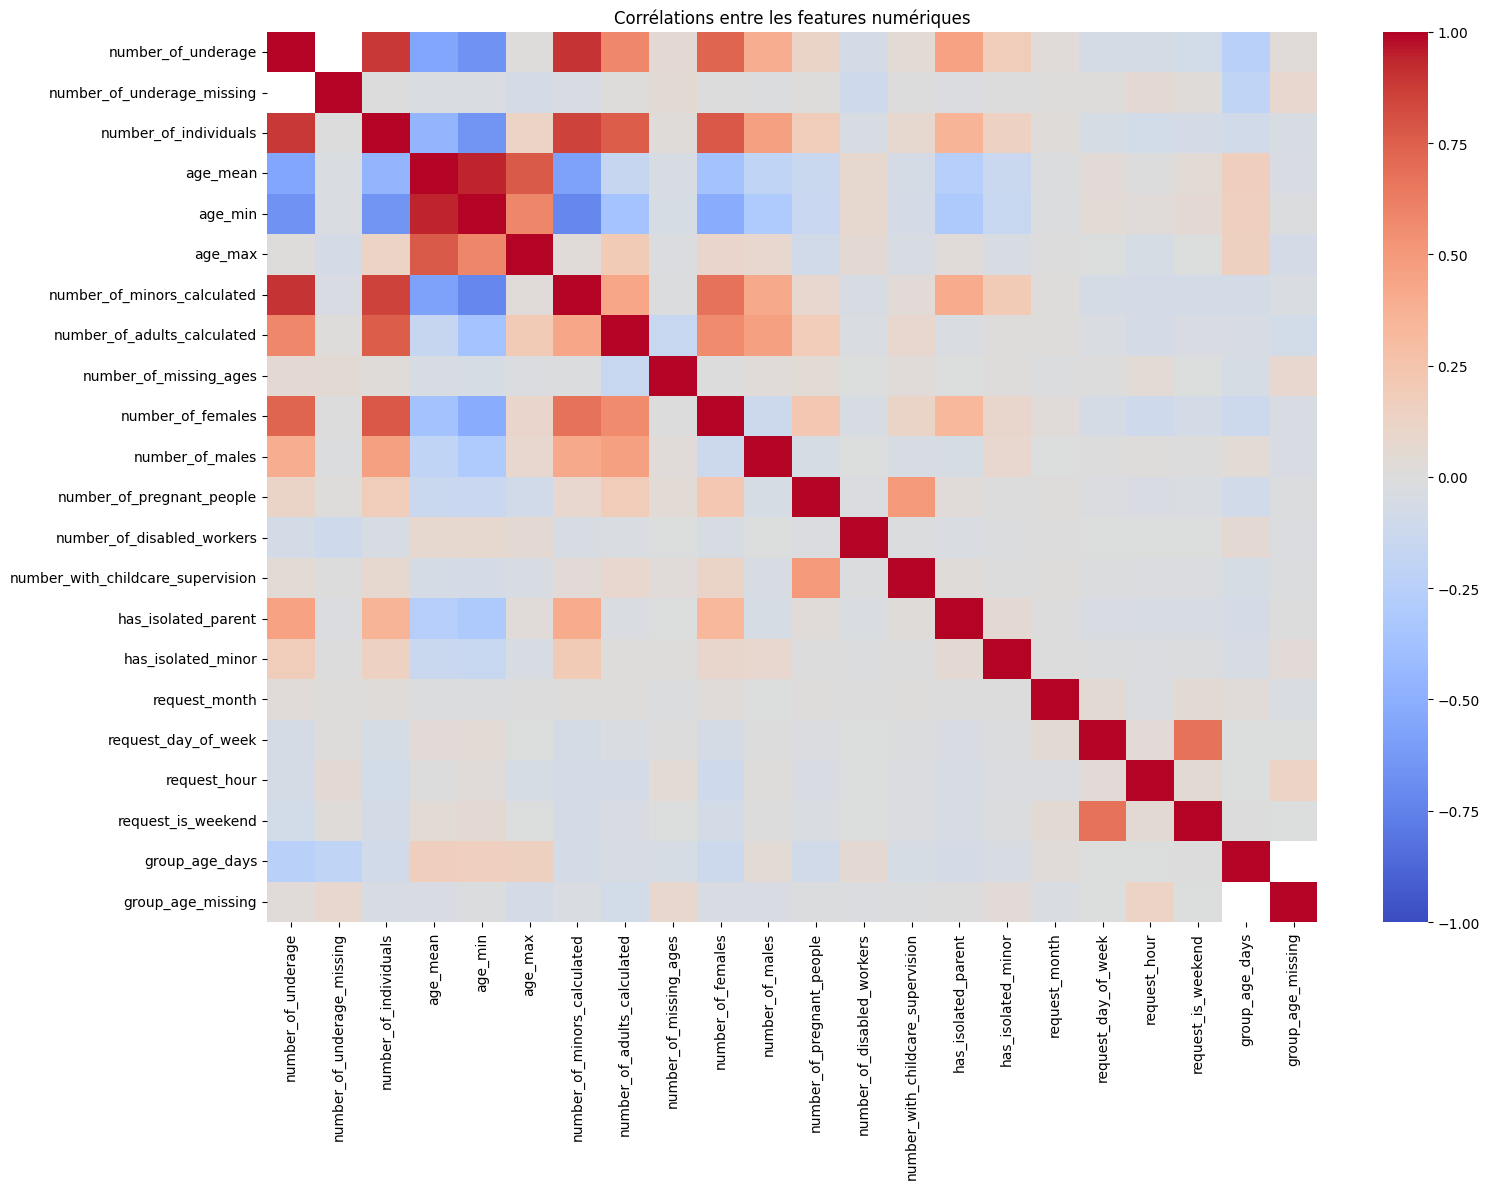

In [83]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Corrélations entre les features numériques")
plt.tight_layout()
plt.show()

# Relations entre les features et la cible

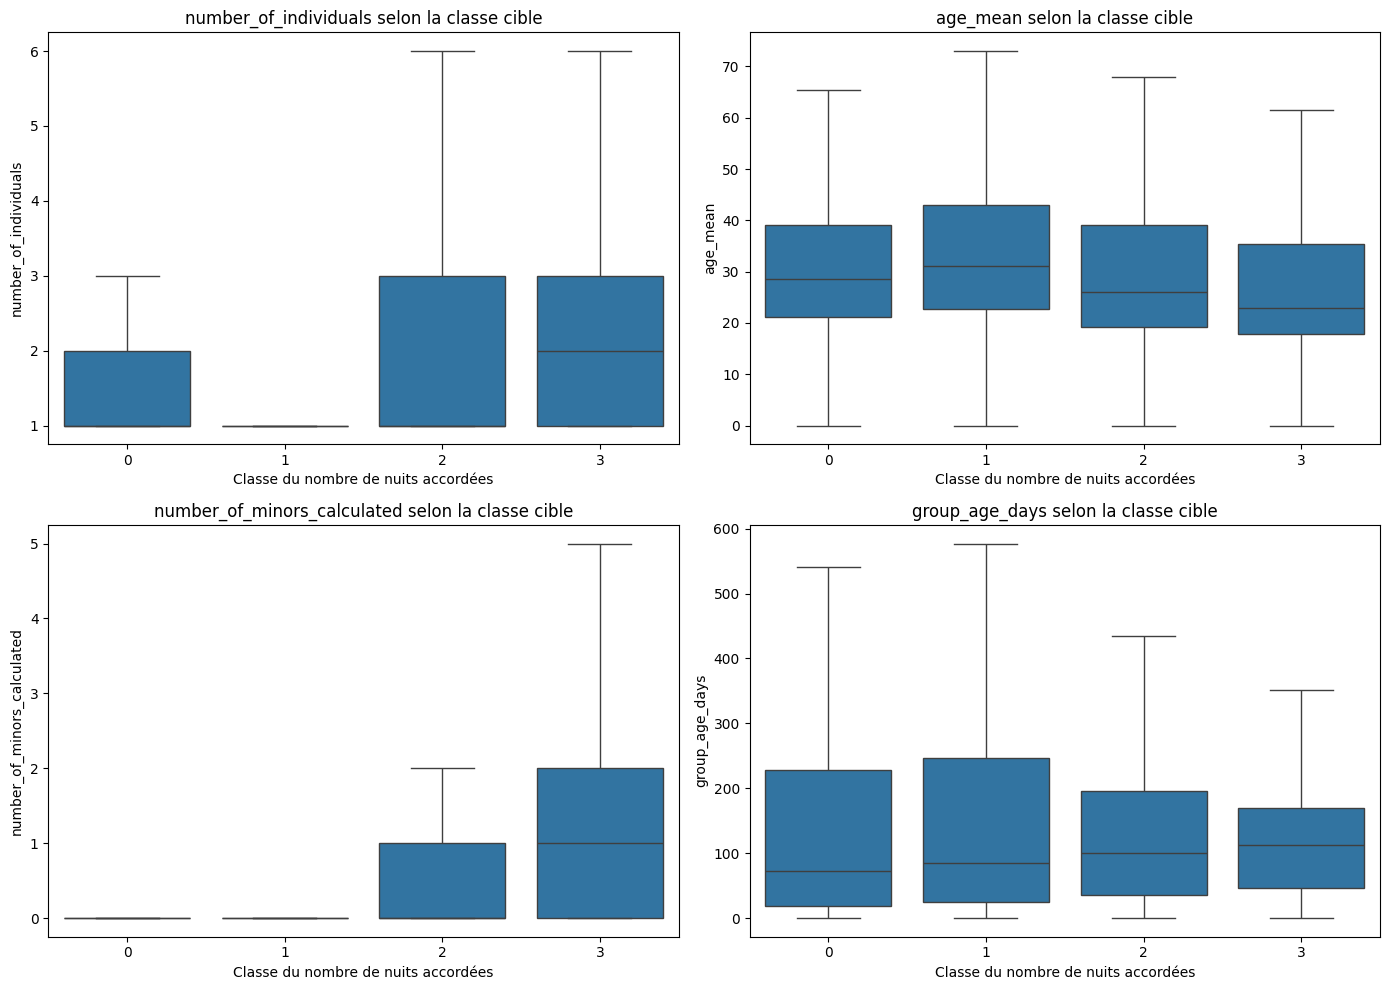

In [84]:
features_to_compare = [
    "number_of_individuals",
    "age_mean",
    "number_of_minors_calculated",
    "group_age_days"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for feature, ax in zip(features_to_compare, axes.flatten()):
    sns.boxplot(
        data=model_data_train,
        x="granted_number_of_nights",
        y=feature,
        ax=ax,
        showfliers=False
    )

    ax.set_title(f"{feature} selon la classe cible")
    ax.set_xlabel("Classe du nombre de nuits accordées")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

# relations entre les variables catégorielles et la cible

In [85]:
group_type_target = pd.crosstab(
    model_data_train["group_type"],
    model_data_train["granted_number_of_nights"],
    normalize="index"
).mul(100).round(2)

display(group_type_target)

granted_number_of_nights,0,1,2,3
group_type,,,,
group,53.05,22.76,21.99,2.20
individual,47.31,38.84,13.20,0.65


In [86]:
violence_target = pd.crosstab(
    model_data_train["victim_of_violence"],
    model_data_train["granted_number_of_nights"],
    normalize="index"
).mul(100).round(2)

display(violence_target)

granted_number_of_nights,0,1,2,3
victim_of_violence,,,,
f,49.06,34.49,15.39,1.05
t,41.69,24.27,31.16,2.88


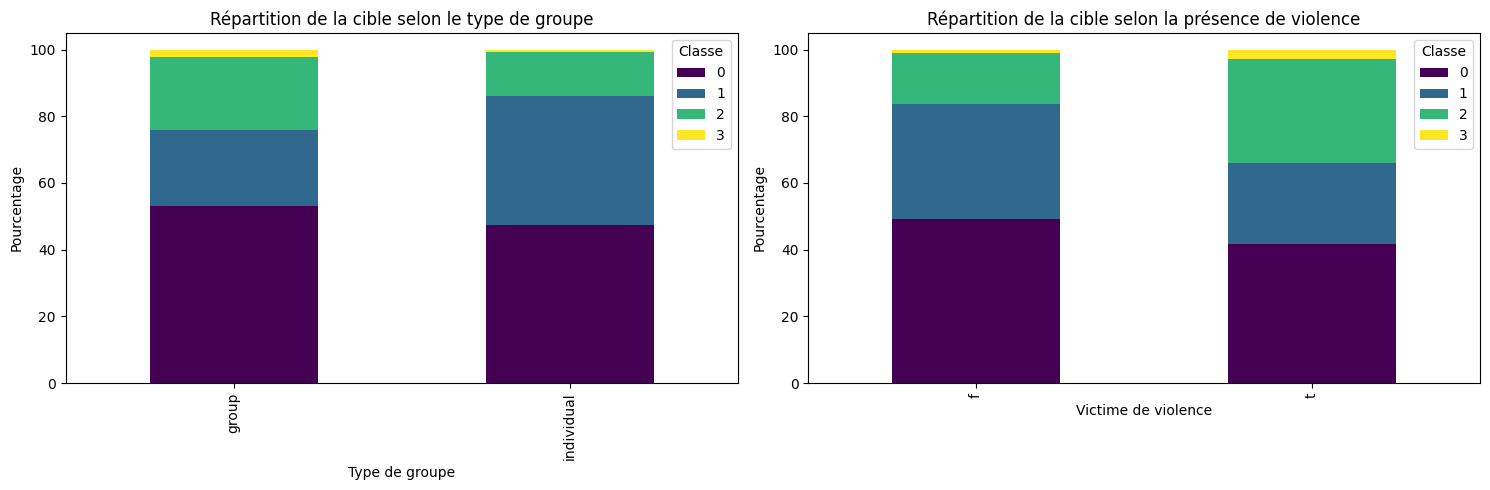

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

group_type_target.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    colormap="viridis"
)

axes[0].set_title("Répartition de la cible selon le type de groupe")
axes[0].set_xlabel("Type de groupe")
axes[0].set_ylabel("Pourcentage")
axes[0].legend(title="Classe")

violence_target.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    colormap="viridis"
)

axes[1].set_title("Répartition de la cible selon la présence de violence")
axes[1].set_xlabel("Victime de violence")
axes[1].set_ylabel("Pourcentage")
axes[1].legend(title="Classe")

plt.tight_layout()
plt.show()

# On continue avec deux variables catégorielles importantes

In [88]:
def plot_target_by_category(
    df,
    feature,
    target="granted_number_of_nights",
    top_n=10
):
    # Catégories les plus fréquentes
    top_categories = (
        df[feature]
        .value_counts()
        .head(top_n)
        .index
    )

    filtered_df = df[df[feature].isin(top_categories)]

    # Pourcentage de chaque classe dans chaque catégorie
    table = pd.crosstab(
        filtered_df[feature],
        filtered_df[target],
        normalize="index"
    ).mul(100).round(2)

    # Trier selon la fréquence des catégories
    table = table.reindex(top_categories)

    table.plot(
        kind="barh",
        stacked=True,
        figsize=(12, 7),
        colormap="viridis"
    )

    plt.title(f"Répartition de la cible selon {feature}")
    plt.xlabel("Pourcentage")
    plt.ylabel(feature)
    plt.legend(title="Classe", bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()

    return table

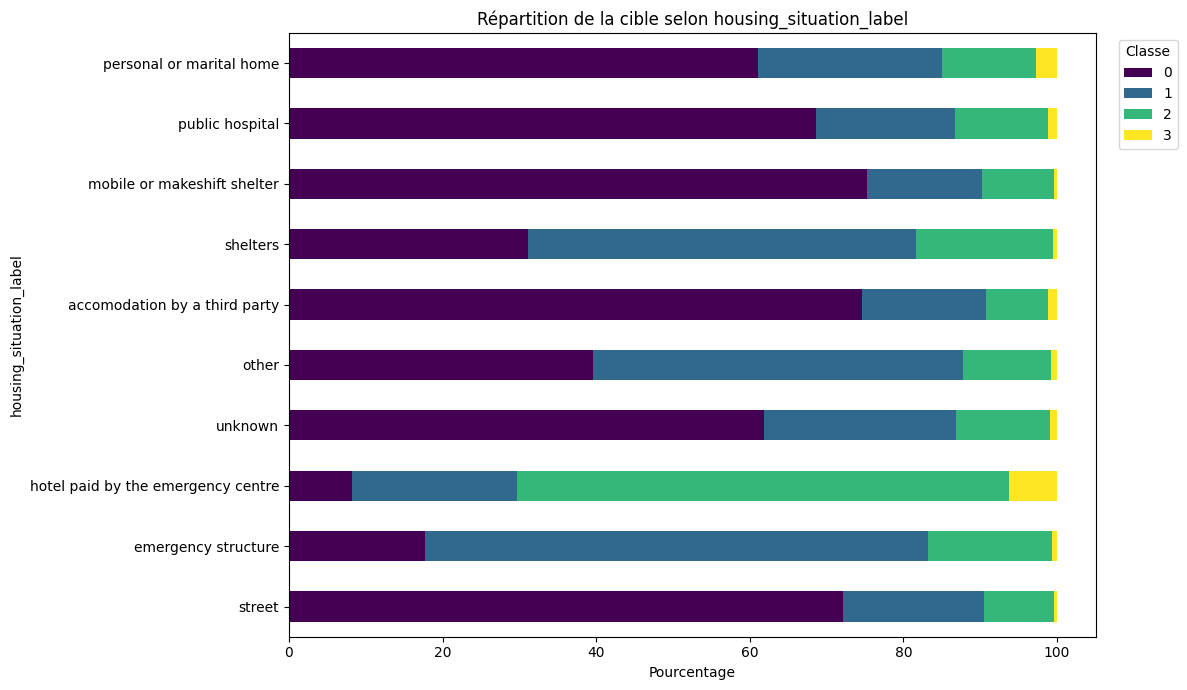

granted_number_of_nights,0,1,2,3
housing_situation_label,,,,
street,72.19,18.34,9.06,0.42
emergency structure,17.76,65.42,16.12,0.71
hotel paid by the emergency centre,8.25,21.45,64.03,6.27
unknown,61.89,24.95,12.25,0.92
other,39.56,48.15,11.50,0.79
accomodation by a third party,74.58,16.11,8.12,1.19
shelters,31.08,50.50,17.86,0.57
mobile or makeshift shelter,75.28,14.90,9.43,0.39
public hospital,68.62,18.06,12.12,1.20


In [89]:
housing_target = plot_target_by_category(
    model_data_train,
    "housing_situation_label",
    top_n=10
)

display(housing_target)

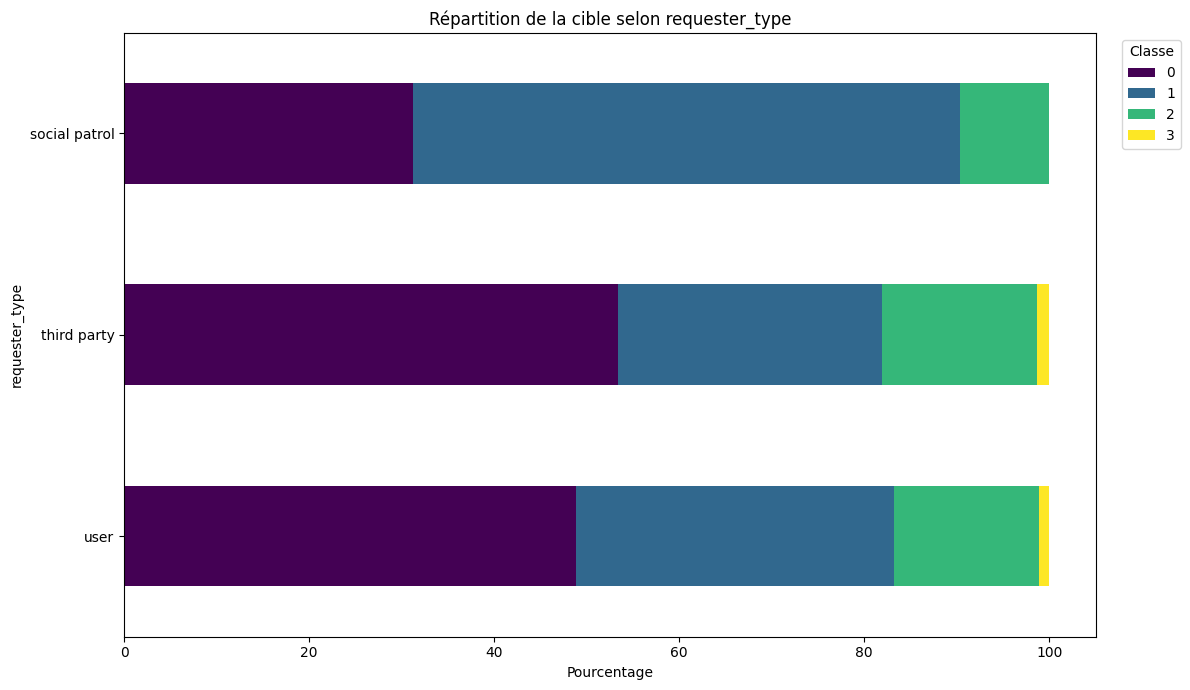

granted_number_of_nights,0,1,2,3
requester_type,,,,
user,48.89,34.36,15.67,1.08
third party,53.37,28.52,16.75,1.36
social patrol,31.27,59.07,9.65,0.00


In [90]:
requester_target = plot_target_by_category(
    model_data_train,
    "requester_type",
    top_n=10
)

display(requester_target)

# Séparer la cible 

In [91]:
target = "granted_number_of_nights"

columns_to_exclude = [
    target,
    "answer_creation_date",
    "request_id",
    "group_id",
    "group_main_requester_id",
    "social_situation_id",
    "request_creation_date",
    "group_creation_date"
]

X = model_data_train.drop(
    columns=columns_to_exclude,
    errors="ignore"
)

y = model_data_train[target].copy()

In [92]:
X_test = model_data_test.drop(
    columns=columns_to_exclude,
    errors="ignore"
)

y_test = model_data_test[target].copy()

In [93]:
print("X :", X.shape)
print("y :", y.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

assert list(X.columns) == list(X_test.columns)

print("Train et test possèdent les mêmes features.")

X : (238191, 38)
y : (238191,)
X_test : (59548, 38)
y_test : (59548,)
Train et test possèdent les mêmes features.


In [94]:
constant_columns = [
    column for column in X.columns
    if X[column].nunique(dropna=False) <= 1
]

print("Colonnes constantes :", constant_columns)

Colonnes constantes : ['request_year']


In [95]:
X = X.drop(columns=constant_columns)
X_test = X_test.drop(columns=constant_columns)

In [96]:
categorical_summary = pd.DataFrame({
    "type": X.dtypes,
    "nombre_valeurs_uniques": X.nunique(dropna=False)
})

categorical_summary = categorical_summary[
    categorical_summary["type"] == "object"
].sort_values(
    "nombre_valeurs_uniques",
    ascending=False
)

display(categorical_summary)

,type,nombre_valeurs_uniques
town,object,1117
request_backoffice_creator_id,object,1069
district,object,102
housing_situation_id,object,22
housing_situation_label,object,22
group_composition_id,object,12
group_composition_label,object,12
victim_of_violence_type,object,8
child_situation,object,8
child_to_come,object,3


# Separation train validation

In [97]:
from sklearn.model_selection import StratifiedGroupKFold

groups = model_data_train["group_id"].copy()

splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_indices, validation_indices = next(
    splitter.split(X, y, groups=groups) #garantir que aucun groupe ne soit partagé entre les deux ensembles
)

In [98]:
X_train = X.iloc[train_indices].copy()
X_validation = X.iloc[validation_indices].copy()

y_train = y.iloc[train_indices].copy()
y_validation = y.iloc[validation_indices].copy()

In [99]:
groups_train = groups.iloc[train_indices]
groups_validation = groups.iloc[validation_indices]

In [100]:
print("X_train :", X_train.shape)
print("X_validation :", X_validation.shape)

print("y_train :", y_train.shape)
print("y_validation :", y_validation.shape)

X_train : (189742, 37)
X_validation : (48449, 37)
y_train : (189742,)
y_validation : (48449,)


In [101]:
common_groups = set(groups_train).intersection(
    set(groups_validation)
)

print(
    "Nombre de groupes présents dans les deux ensembles :",
    len(common_groups)
)

assert len(common_groups) == 0

Nombre de groupes présents dans les deux ensembles : 0


In [102]:
class_distribution = pd.DataFrame({
    "Données complètes": y.value_counts(normalize=True).sort_index(),
    "Train": y_train.value_counts(normalize=True).sort_index(),
    "Validation": (
        y_validation.value_counts(normalize=True).sort_index()
    )
}).mul(100).round(2)

display(class_distribution)

,Données complètes,Train,Validation
granted_number_of_nights,,,
0,48.93,48.88,49.11
1,34.31,34.28,34.42
2,15.68,15.75,15.40
3,1.09,1.09,1.08


# Catboost

In [103]:
from catboost import CatBoostClassifier, Pool

In [104]:
X_train_cb = X_train.copy()
X_validation_cb = X_validation.copy()
X_test_cb = X_test.copy()

In [105]:
categorical_columns = X_train_cb.select_dtypes(
    include=["object"]
).columns.tolist()

print(
    "Nombre de variables catégorielles :",
    len(categorical_columns)
)

print(categorical_columns)

Nombre de variables catégorielles : 15
['animal_presence', 'child_situation', 'child_to_come', 'district', 'group_composition_id', 'group_composition_label', 'group_type', 'housing_situation_id', 'housing_situation_label', 'long_term_housing_request', 'request_backoffice_creator_id', 'requester_type', 'town', 'victim_of_violence', 'victim_of_violence_type']


In [106]:
train_sample_weights = 10 ** y_train.to_numpy()
validation_sample_weights = 10 ** y_validation.to_numpy()

In [107]:
train_pool = Pool(
    data=X_train_cb,
    label=y_train,
    cat_features=categorical_columns,
    weight=train_sample_weights
)

validation_pool = Pool(
    data=X_validation_cb,
    label=y_validation,
    cat_features=categorical_columns,
    weight=validation_sample_weights
)

In [ ]:
catboost_model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="MultiClass",
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=5,
    random_seed=42,
    verbose=100,
    allow_writing_files=False
)

catboost_model.fit(
    train_pool,
    eval_set=validation_pool,
    early_stopping_rounds=100,
    use_best_model=True
)

In [ ]:
catboost_validation_predictions = (
    catboost_model.predict_proba(X_validation_cb)
)

catboost_score = competition_scorer(
    y_validation,
    catboost_validation_predictions
)

print(f"Score CatBoost : {catboost_score:.4f}")

In [ ]:
catboost_model.save_model(
    "/kaggle/working/catboost_model.cbm"
)

print("Modèle CatBoost enregistré.")

# Essayer d'autre hyperparamtre de catboost

In [ ]:
catboost_model_v2 = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="MultiClass",

    iterations=1500,
    learning_rate=0.03,
    depth=7,
    l2_leaf_reg=10, #reduire le surapp

    random_strength=0.5,
    bagging_temperature=0.5,

    random_seed=42,
    verbose=100,
    allow_writing_files=False
)

In [ ]:
catboost_model_v2.fit(
    train_pool,
    eval_set=validation_pool,
    early_stopping_rounds=100,
    use_best_model=True
)

In [ ]:
catboost_predictions_v2 = (
    catboost_model_v2.predict_proba(X_validation_cb)
)

catboost_score_v2 = competition_scorer(
    y_validation,
    catboost_predictions_v2
    
)

In [ ]:
comparison = pd.DataFrame({
    "Modèle": [
        "CatBoost initial",
        "CatBoost V2"
    ],
    "Score validation": [
        catboost_score,
        catboost_score_v2
    ],
    "Meilleure itération": [
        catboost_model.get_best_iteration(),
        catboost_model_v2.get_best_iteration()
    ]
}).sort_values("Score validation")

display(comparison)

In [ ]:
catboost_model_v2.save_model(
    "/kaggle/working/catboost_best_model.cbm"
)

print("Meilleur modèle CatBoost enregistré.")